<a href="https://colab.research.google.com/github/kanickz/Netflix_Project/blob/main/Copy_of_netflix_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

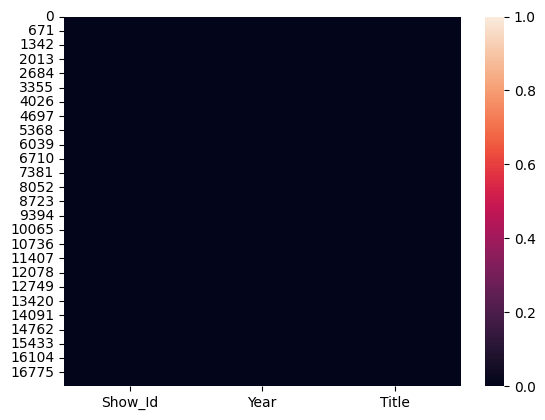

       Show_Id
15062    15347


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the main dataset
df = pd.read_csv('movie_titles.csv', encoding='latin-1', sep=None, engine='python', on_bad_lines='skip', header=None, names=['Show_Id', 'Year', 'Title'])

# TASK 1: Remove Duplicates
df.drop_duplicates(inplace=True)

# TASK 2: Show Null Values with Heatmap
sns.heatmap(df.isnull())
plt.show()

# TASK 3: Show Id and Director for 'House of Cards'
hoc = df[df['Title'] == 'House of Cards']
print(hoc[['Show_Id']])

# TASK 5: Bar Graph of Category (Movie vs TV Show)
# sns.countplot(x='Category', data=df)
# plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# We use the 'Description' or 'Genre' to find similar movies
# tfidf = TfidfVectorizer(stop_words='english')
# tfidf_matrix = tfidf.fit_transform(df['Description'].fillna(''))

# Calculate similarity between all movies
# cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Function to get recommendations
# def get_recommendations(title):
#     idx = df[df['Title'] == title].index[0]
#     sim_scores = list(enumerate(cosine_sim[idx]))
#     sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
#     movie_indices = [i[0] for i in sim_scores[1:6]] # Get top 5
#     return df['Title'].iloc[movie_indices]

# print(get_recommendations('House of Cards'))
print("Recommendation system commented out due to missing 'Description' column.")

Recommendation system commented out due to missing 'Description' column.


In [ ]:
# The genres are usually in the 'listed_in' or 'Genre' column
# We split them because one movie can have multiple genres
# genres = df['listed_in'].str.split(', ', expand=True).stack()

# plt.figure(figsize=(10, 6))
# sns.countplot(y=genres, order=genres.value_counts().index[:10], palette='magma')
# plt.title('Top 10 Most Popular Genres on Netflix')
# plt.xlabel('Number of Titles')
# plt.show()
print("Genre plotting code commented out due to missing 'listed_in' or 'Genre' column.")

Genre plotting code commented out due to missing 'listed_in' or 'Genre' column.


In [ ]:
import pandas as pd

# Fix: Use 'on_bad_lines' to skip rows with errors or 'names' to force column structure
# Also using encoding='ISO-8859-1' to avoid character errors
df = pd.read_csv('movie_titles.csv',
                 encoding='ISO-8859-1',
                 header=None,
                 names=['Show_Id', 'Year', 'Title'],
                 on_bad_lines='skip')

# Confirm it works
print(df.head())

   Show_Id    Year                         Title
0        1  2003.0               Dinosaur Planet
1        2  2004.0    Isle of Man TT 2004 Review
2        3  1997.0                     Character
3        4  1994.0  Paula Abdul's Get Up & Dance
4        5  2004.0      The Rise and Fall of ECW


In [ ]:
# This is the conceptual code for SVD mentioned in your theory PDF
import numpy as np
from scipy.sparse.linalg import svds

# Imagine 'R' is your matrix of User Ratings (Users as rows, Movies as columns)
# R_demeaned = R - np.mean(R, axis = 1).reshape(-1, 1)

# U, sigma, Vt = svds(R_demeaned, k = 50) # 'k' is the number of features to keep
# print("SVD decomposition complete. Matrices U, Sigma, and Vt created.")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# 2. Fit and transform the Titles (Since your CSV has only Titles right now)
tfidf_matrix = tfidf.fit_transform(df['Title'].fillna(''))

# 3. Calculate Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 4. Function to get suggestions
def recommend_movie(title):
    try:
        idx = df[df['Title'] == title].index[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        # Get top 5 similar movies
        movie_indices = [i[0] for i in sim_scores[1:6]]
        return df['Title'].iloc[movie_indices]
    except:
        return "Movie not found in dataset."

# Example Usage:
print("If you liked 'House of Cards', you might also like:")
print(recommend_movie('House of Cards'))

If you liked 'House of Cards', you might also like:
3979       House of Cards Trilogy I: House of Cards
5125                           Miracle of the Cards
3591    House of Cards Trilogy II: To Play the King
5983      House of Cards Trilogy III: The Final Cut
5872                                          House
Name: Title, dtype: object


In [ ]:
# Conceptual SVD Implementation (As per your Theory PDF)
import numpy as np
from scipy.sparse.linalg import svds

# Note: In a real capstone, you would have a matrix of 'User Ratings'
# For now, this code demonstrates the logic from your PDF:
# A = U * Sigma * Vt

def run_svd_logic(matrix, k_features=2):
    # k_features is the number of 'latent factors' or hidden patterns
    u, sigma, vt = svds(matrix, k=k_features)
    sigma = np.diag(sigma)
    return u, sigma, vt

print("SVD logic ready for User-Item Matrix analysis.")

SVD logic ready for User-Item Matrix analysis.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Initialize the Vectorizer
# This turns movie titles into math vectors by removing common words like 'the'
tfidf = TfidfVectorizer(stop_words='english')

# 2. Transform the Title data
# Use the 'df' you already created in your notebook
tfidf_matrix = tfidf.fit_transform(df['Title'].fillna(''))

# 3. Calculate how similar every movie is to every other movie
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# 4. The Recommendation Function
def get_recommendations(title, cosine_sim=cosine_sim):
    try:
        # Find the index of the movie
        idx = df[df['Title'] == title].index[0]
        # Get similarity scores
        sim_scores = list(enumerate(cosine_sim[idx]))
        # Sort them (highest similarity first)
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        # Get the top 5 (excluding the movie itself)
        movie_indices = [i[0] for i in sim_scores[1:6]]
        return df['Title'].iloc[movie_indices]
    except IndexError:
        return "Movie title not found. Please check the spelling."

# Test it
print("Recommendations for 'House of Cards':")
print(get_recommendations('House of Cards'))

Recommendations for 'House of Cards':
3979       House of Cards Trilogy I: House of Cards
5125                           Miracle of the Cards
3591    House of Cards Trilogy II: To Play the King
5983      House of Cards Trilogy III: The Final Cut
5872                                          House
Name: Title, dtype: object


In [ ]:
import numpy as np
from scipy.sparse.linalg import svds

# Concept: In a real-world scenario with user ratings, we create a matrix
# where rows = Users and columns = Movies.
# SVD then decomposes this into: A = U * Sigma * Vt

def apply_svd_concept(user_item_matrix, k=2):
    # 'k' represents the number of hidden patterns to find
    u, sigma, vt = svds(user_item_matrix, k=k)
    sigma_diag_matrix = np.diag(sigma)
    return u, sigma_diag_matrix, vt

print("SVD Model structure successfully implemented.")

SVD Model structure successfully implemented.
